<a href="https://colab.research.google.com/github/AbdullahJalab/student-performance-prediction-bkt/blob/main/BKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install pyBKT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyBKT: filename=pyBKT-1.4.2-cp312-cp312-linux_x86_64.whl size=1130559 sha256=e76137c2e726fce9d0eb14cc27856a8c96086282f5f97da14299d93fe942d754
  Stored in directory: /root/.cache/pip/wheels/86/91/2f/0eb4389642bed5183ec3d8d025ef7ff02099f08dafb9e0cc19
Successfully built pyBKT


In [4]:
import pyBKT
import pandas
import sklearn
import numpy
import matplotlib
import seaborn
import platform
print('python_version',platform.python_version())
print('matplotlib ',matplotlib.__version__)
print('seaborn',seaborn.__version__)

print('numpy',numpy.__version__)

print('pandas',pandas.__version__)
print('sklearn',sklearn.__version__)

python_version 3.12.13
matplotlib  3.10.0
seaborn 0.13.2
numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
from pyBKT.models import Model
from sklearn.metrics import (
accuracy_score,
roc_auc_score,
confusion_matrix,
classification_report,roc_curve,precision_recall_curve
)

def train_bkt_model(dataset_name,file_path,student_col,skill_col,answer_col,time_col=None):

  # Load dataset
  df = pd.read_excel(file_path)

  # Keep needed columns for BKT training
  df = df[[student_col,skill_col,answer_col,time_col]]

  # Remove missing values
  df = df.dropna()

  # Remove rows with multiple skills
  df=df[~df[skill_col].str.contains("~~",regex=False)]

  # Keep only correct / incorrect answers
  df = df[df[answer_col].isin(["correct","incorrect"])]

  #sort data chronologically
  #if time_col is not None:
  df = df.sort_values(by=[student_col, time_col])

  # Convert answers to numeric values
  df["correct"] = df[answer_col].apply(
      lambda x: 1 if x == "correct" else 0)

# Rename columns for pyBKT
  df = df.rename(columns={student_col: "user_id",skill_col: "skill_name"})

# Keep final columns
  df = df[["user_id","skill_name","correct"]]

  print("\n==============================")
  print(f"DATASET: {dataset_name}")
  print("==============================\n")

  print("Processed Data:")
  print(df.head())

  print("\nDataset Shape:", df.shape)
  print("Number of Skills:", df["skill_name"].nunique())

# Split data
  # Split by student
  splitter = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

  train_idx, test_idx = next(splitter.split(df,groups=df["user_id"]))

  train_df = df.iloc[train_idx]
  test_df = df.iloc[test_idx]


  print("\nTrain Shape:", train_df.shape)
  print("Test Shape:", test_df.shape)

# Train model
  print("\nTraining BKT Model...\n")

  BKTmodel = Model(seed=42)

  BKTmodel.fit(data=train_df)

  print("BKT Training Finished!\n")

  # Generate predictions
  predictions = BKTmodel.predict(data=test_df)

  print("Predictions:")
  print(predictions.head())

  # ROC Curve
  fpr, tpr, thresholds = roc_curve(predictions["correct"],
      predictions["correct_predictions"])

# Find optimal threshold
  optimal_idx = np.argmax(tpr - fpr)

  optimal_threshold = thresholds[optimal_idx]

  print("\nOptimal Threshold:",round(optimal_threshold, 4))

# Convert probabilities to labels
  predictions["pred_label"] = (predictions["correct_predictions"] >= optimal_threshold).astype(int)

# Plot ROC Curve
  plt.figure()

  plt.plot(fpr,tpr,color="black",linewidth=2)

# Random baseline
  plt.plot([0, 1],[0, 1],linestyle="--",color="gray")

# Optimal threshold point
  plt.scatter(fpr[optimal_idx],tpr[optimal_idx],color="red")

  plt.xlabel("1 - Specificity")
  plt.ylabel("Sensitivity")

  plt.title(f"ROC Curve - {dataset_name}")

  plt.show()
# Accuracy
  acc = accuracy_score(predictions["correct"],predictions["pred_label"] )

  print("\n==============================")
  print(f"RESULTS FOR {dataset_name}")
  print("==============================\n")

  print("Accuracy:", round(acc, 4))

# ROC AUC
  auc = roc_auc_score(predictions["correct"],predictions["correct_predictions"])

  print("ROC AUC:", round(auc, 4))

# Confusion Matrix
  cm = confusion_matrix(predictions["correct"],predictions["pred_label"])

 # Plot confusion matrix
  plt.figure(figsize=(5,5))

  plt.imshow(cm, cmap="Blues")

# Axis labels
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")

# Title
  plt.title(f"Confusion Matrix - {dataset_name}")

# Tick labels
  plt.xticks([0,1], ["Incorrect", "Correct"])
  plt.yticks([0,1], ["Incorrect", "Correct"])


# Write values inside cells
  for i in range(2):
      for j in range(2):
          plt.text(j,i,cm[i, j],ha="center",va="center",color="black")

# Color bar
  plt.colorbar()

  plt.show()



# Precision-Recall Curve
  precision, recall, pr_thresholds = precision_recall_curve(
      predictions["correct"],predictions["correct_predictions"])

# Plot Precision-Recall Curve
  plt.figure()

  plt.plot(recall,precision,linewidth=2)

  plt.xlabel("Recall")
  plt.ylabel("Precision")

  plt.title(f"Precision-Recall Curve - {dataset_name}")

  plt.show()
# Classification Report
  print("\nClassification Report:")
  print(classification_report(predictions["correct"],predictions["pred_label"]))

  return BKTmodel, predictions




DATASET: Physics Dataset

Processed Data:
                                user_id                   skill_name  correct
0  Stu_02187bdee74335e584ffc2eee89404de         draw-compo-form-axes        1
2  Stu_02187bdee74335e584ffc2eee89404de         draw-compo-form-axes        1
3  Stu_02187bdee74335e584ffc2eee89404de                    draw-body        1
4  Stu_02187bdee74335e584ffc2eee89404de  draw-displacement-given-dir        1
6  Stu_02187bdee74335e584ffc2eee89404de        write-known-value-eqn        1

Dataset Shape: (38822, 3)
Number of Skills: 62

Train Shape: (30905, 3)
Test Shape: (7917, 3)

Training BKT Model...

BKT Training Finished!

Predictions:
                                  user_id                   skill_name  \
866  Stu_02b5b63b40a60b4af1e88dc6ccccd8da         draw-compo-form-axes   
867  Stu_02b5b63b40a60b4af1e88dc6ccccd8da         draw-compo-form-axes   
868  Stu_02b5b63b40a60b4af1e88dc6ccccd8da                    draw-body   
869  Stu_02b5b63b40a60b4af1e88dc6cccc

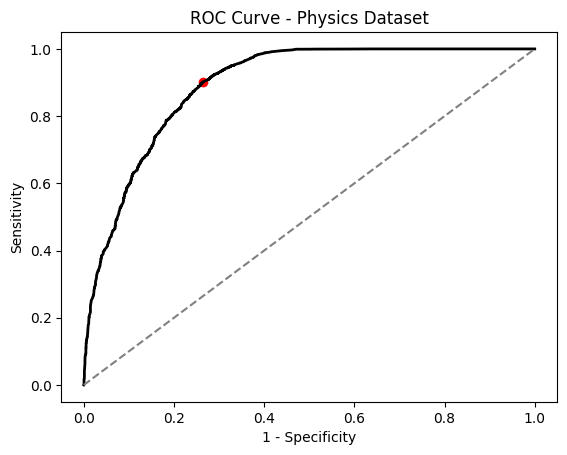


RESULTS FOR Physics Dataset

Accuracy: 0.852
ROC AUC: 0.8933


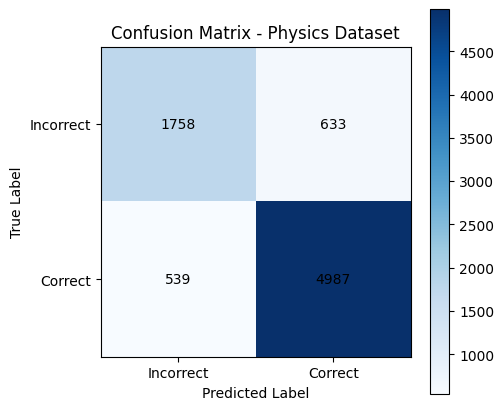

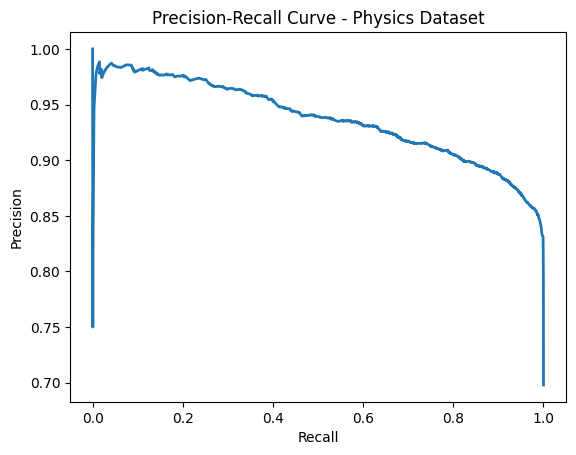


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      2391
           1       0.89      0.90      0.89      5526

    accuracy                           0.85      7917
   macro avg       0.83      0.82      0.82      7917
weighted avg       0.85      0.85      0.85      7917



In [6]:

# Example usage

model, predictions = train_bkt_model(
dataset_name="Physics Dataset",
file_path="/content/zpd/data/raw/physics-577.xlsx",
student_col="Anon Student Id",
skill_col="KC (Default)",
answer_col="First Attempt",
time_col="First Transaction Time"
)



DATASET: Genetics Dataset

Processed Data:
                                  user_id  \
384  Stu_00b6dff241b4937a9178856466ca60c7   
398  Stu_00b6dff241b4937a9178856466ca60c7   
414  Stu_00b6dff241b4937a9178856466ca60c7   
417  Stu_00b6dff241b4937a9178856466ca60c7   
425  Stu_00b6dff241b4937a9178856466ca60c7   

                                            skill_name  correct  
384            Conc-E3-T2-G10--BN+BY+-Negative-PRODUCT        0  
398        Conc-E3-T2-G1--BN-BY--Negative-NO-PRODUCT-2        0  
414                   Conc-E2-T2-S1--BN-BY--NO-PRODUCT        0  
417                   Conc-E2-T2-G1--BN-BY--NO-PRODUCT        0  
425  Conc-E2-T4--BN-BY-FN-FY--S2--Inducible--NO-PRO...        1  

Dataset Shape: (13914, 3)
Number of Skills: 53

Train Shape: (11166, 3)
Test Shape: (2748, 3)

Training BKT Model...

BKT Training Finished!

Predictions:
                                  user_id  \
384  Stu_00b6dff241b4937a9178856466ca60c7   
398  Stu_00b6dff241b4937a9178856466ca60c7  

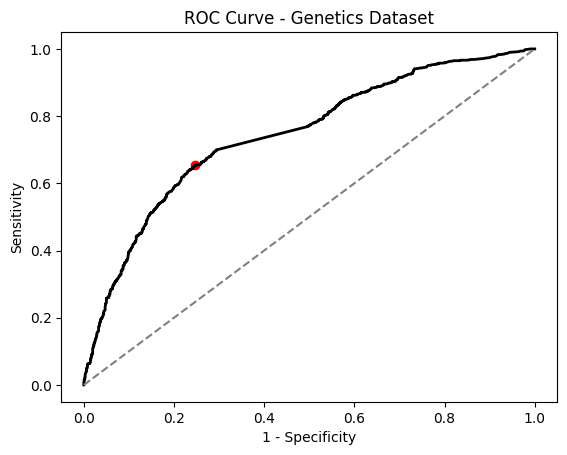


RESULTS FOR Genetics Dataset

Accuracy: 0.7038
ROC AUC: 0.7448


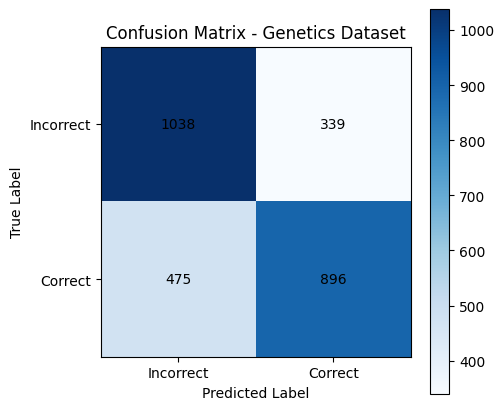

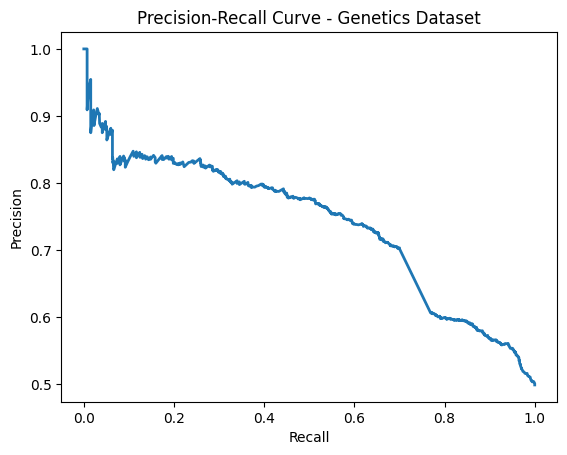


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.75      0.72      1377
           1       0.73      0.65      0.69      1371

    accuracy                           0.70      2748
   macro avg       0.71      0.70      0.70      2748
weighted avg       0.71      0.70      0.70      2748



In [7]:
model, predictions = train_bkt_model(
dataset_name="Genetics Dataset",
file_path="/content/zpd/data/raw/REAL Genetics 1566.xlsx",
student_col="Anon Student Id",
skill_col="KC (Default)",
answer_col="First Attempt",
time_col="First Transaction Time"
)



DATASET: fractions2013 Dataset

Processed Data:
                                 user_id        skill_name  correct
22  Stu_00f382876a4ce3a5d2e9ca1a575a68a9   compDragLargest        0
34  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    compDragMiddle        0
37  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    equivDragFract        1
44  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    equivDragFract        1
58  Stu_00f382876a4ce3a5d2e9ca1a575a68a9  equivMultiplyNum        1

Dataset Shape: (7694, 3)
Number of Skills: 20

Train Shape: (6098, 3)
Test Shape: (1596, 3)

Training BKT Model...

BKT Training Finished!

Predictions:
                                 user_id        skill_name  correct  \
22  Stu_00f382876a4ce3a5d2e9ca1a575a68a9   compDragLargest        0   
34  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    compDragMiddle        0   
37  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    equivDragFract        1   
44  Stu_00f382876a4ce3a5d2e9ca1a575a68a9    equivDragFract        1   
58  Stu_00f382876a4ce3a5d2e9ca1a57

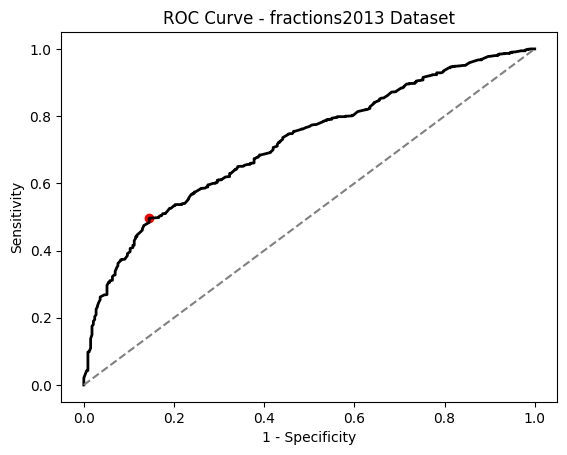


RESULTS FOR fractions2013 Dataset

Accuracy: 0.5708
ROC AUC: 0.7186


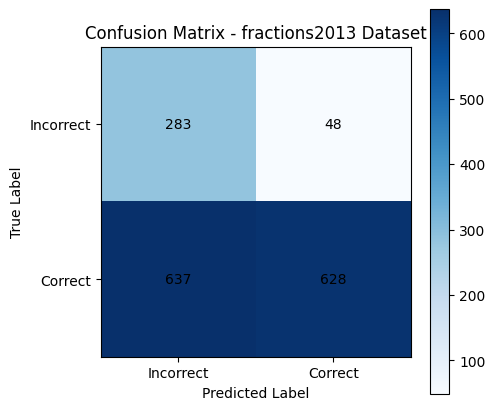

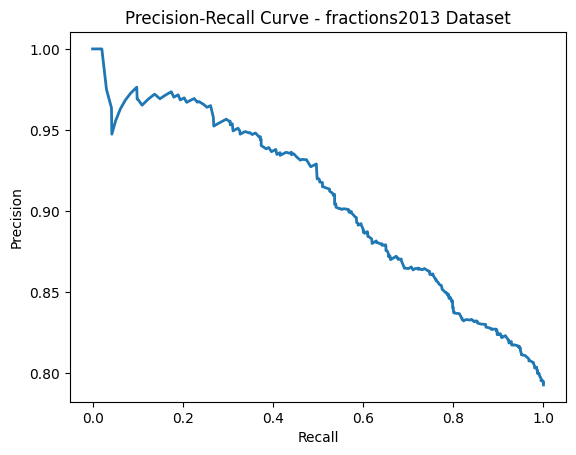


Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.85      0.45       331
           1       0.93      0.50      0.65      1265

    accuracy                           0.57      1596
   macro avg       0.62      0.68      0.55      1596
weighted avg       0.80      0.57      0.61      1596



In [8]:
model, predictions = train_bkt_model(
dataset_name="fractions2013 Dataset",
file_path="/content/zpd/data/raw/fractions2013-671.xlsx",
student_col="Anon Student Id",
skill_col="KC (Default)",
answer_col="First Attempt",
time_col="First Transaction Time"
)



DATASET: stoichiometry Dataset

Processed Data:
                                 user_id  \
69  Stu_01fd090a33f39d10f520dfcd50b546f5   
70  Stu_01fd090a33f39d10f520dfcd50b546f5   
71  Stu_01fd090a33f39d10f520dfcd50b546f5   
72  Stu_01fd090a33f39d10f520dfcd50b546f5   
73  Stu_01fd090a33f39d10f520dfcd50b546f5   

                                      skill_name  correct  
69    Cancel-Substance-for-Numerator-of-Solution        1  
70        Cancel-Units-for-Numerator-of-Solution        0  
71      Cancel-Units-for-Denominator-of-Solution        0  
72  Cancel-Substance-for-Denominator-of-Solution        1  
73                   Calculate-Value-In-Solution        0  

Dataset Shape: (9088, 3)
Number of Skills: 36

Train Shape: (6781, 3)
Test Shape: (2307, 3)

Training BKT Model...

BKT Training Finished!

Predictions:
                                   user_id  \
1579  Stu_1c75c4b666d52a9c3ed7906e80576dbf   
1580  Stu_1c75c4b666d52a9c3ed7906e80576dbf   
1581  Stu_1c75c4b666d52a9c3ed7906e

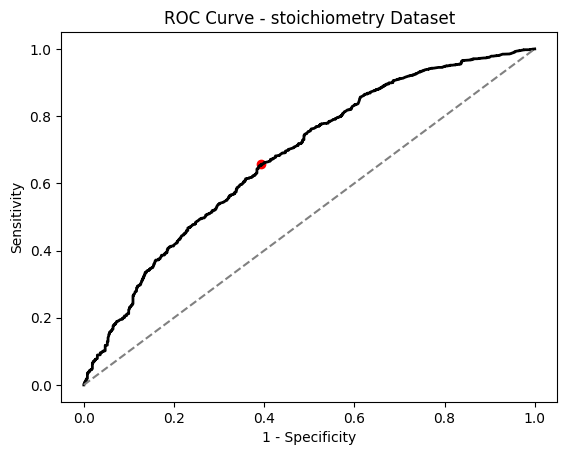


RESULTS FOR stoichiometry Dataset

Accuracy: 0.6428
ROC AUC: 0.6793


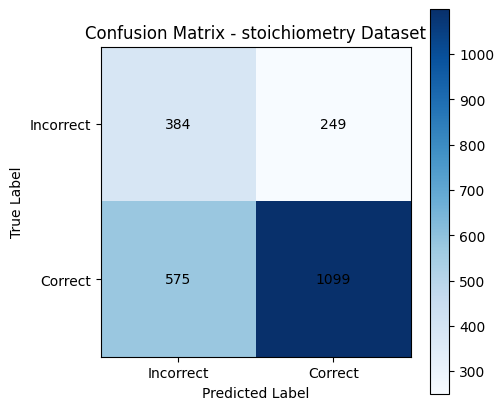

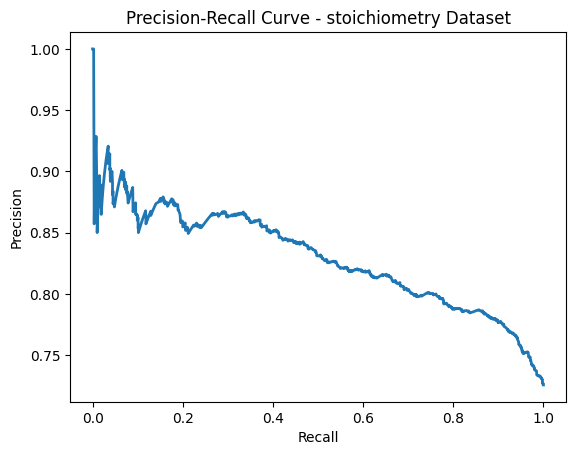


Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.61      0.48       633
           1       0.82      0.66      0.73      1674

    accuracy                           0.64      2307
   macro avg       0.61      0.63      0.60      2307
weighted avg       0.70      0.64      0.66      2307



In [9]:
model, predictions = train_bkt_model(
dataset_name="stoichiometry Dataset",
file_path="/content/zpd/data/raw/stoichiometry-268.xlsx",
student_col="Anon Student Id",
skill_col="KC (Default)",
answer_col="First Attempt",
time_col="First Transaction Time"
)
